### Report - Predicting Churn for E-Commerce Retail store using behavioural data.

How does one assess the likelihood of churn? What can be done to improve customer retention? I am sure many owners/executives of either online stores or retail stores are looking at monthly churn or retention numbers and asking how can these metrics be improved for the company? I chose this project because I am interested in building a model that can best predict churn given a set of high-dimensional data. In this project, I will assess churn data sourced from Kaggle, identify what variables I think have the most impact, and compare different prediction models to show which model I think has the most accuracy and precision to use for predicting customer churn. Churn here is defined as a customer who has not made any purchase in the previous 6 months.

Key non-technical takeaways:
1) There are 112,610 observations, with 276 dimensions. There were no null data points.
2) The data was split 50-50 between training and testing data.
3) 5 different predictive models were tested with different algorithms.
4) Our best performing model was Gradient Boosting with an accuracy score of 0.86, with the worst performing model being Naïve Bayes with accuracy score of 0.53. The scores are shown in Appendix, Chart 6.
5) Our recommendation is that this model can be trained, and used against new data sets (or ‘test’ data) to assess likelihood of customer churn

Notes: Data Sourced from Kaggle

https://www.kaggle.com/datasets/fridrichmrtn/e-commerce-churn-dataset-rees46

https://www.kaggle.com/datasets/fridrichmrtn/e-commerce-churn-dataset-retail-rocket

Fridrich, M. (2023). Machine Learning in Customer Churn Prediction [Dissertation Thesis]. Brno University of Technology, Faculty of Business and Management. Supervised by Petr Dostál.



### 1 Load Libraries 

#### Report 

The dataset I am using is sourced from Kaggle. This dataset in turn was sourced OpenCDP project, where they collected events from an online merchant that were tracked for each subscriber/consumer. Thus, this was real data. This behaviour data was tracked for 7 months (from October 2019 till April 2020) from a large multi-category online store. Each event has 270 predictors, with 6 variables considered part of the target variables. There are 276 dimensions in the dataset. 2 are ID variables, 6 are target variable group, 217 are numerical and 51 are date-type variables. There were no categorical variables in this dataset.

The following steps were taken to pre-process the dataset. This dataset has 112,610 observations, with 276 dimensions. Out of these, 6 variables are considered target values, hence, they were removed from the training dataset. These were target_event, target_revenue, target_customer_value, time_step, target_customer_value_lag1, target_actual_profit. Then I removed the 2 columns as mentioned above that were ID variables, row_id and user_id. The rest of the data, excluding the 6 target variables and 2 id variables, were copied to mod_X. Mod_X in effect contains all the predictor variables and their values. A new variable was created called mod_Y. The data from the target_event was copied to the mod_Y variable. Target_event=1 equals churn, and 0 equals non-churn. Therefore, any data split will be handled from mod_X (scaled version) and mod_Y.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold, RepeatedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

warnings.filterwarnings("ignore")


### 2 Loading Data

In [2]:
model = pd.read_csv("rees46_customer_model.csv",sep=",")

In [3]:
model.shape

(112610, 276)

In [4]:
mod_X = model.drop(['row_id','user_id','target_event','target_actual_profit','target_revenue','target_customer_value','time_step','target_customer_value_lag1'], axis=1)
#Dropped target_actual_profit because it is also related to target variable.
mod_Y = model['target_event']

In [5]:
#Set this option if you want to see all variables.
#pd.set_option('display.max_columns', None)
#pd.set_option('display.max_rows', None)

In [6]:
#Scale data before doing splits
scaler = StandardScaler()
X_scaled = scaler.fit_transform(mod_X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, mod_Y, test_size=0.5, random_state=44)

#### Report (Continued)



Next, we assessed which variables are accounting for the largest amount of variance in the training set. Using PCA analysis, we found that session_time, session_recency, purchase_time, time_to_click, time_to_purchase, time_to_view, purchase_recency among them that had the largest amount of variance in the training set.

### 3 Running PCA Analysis

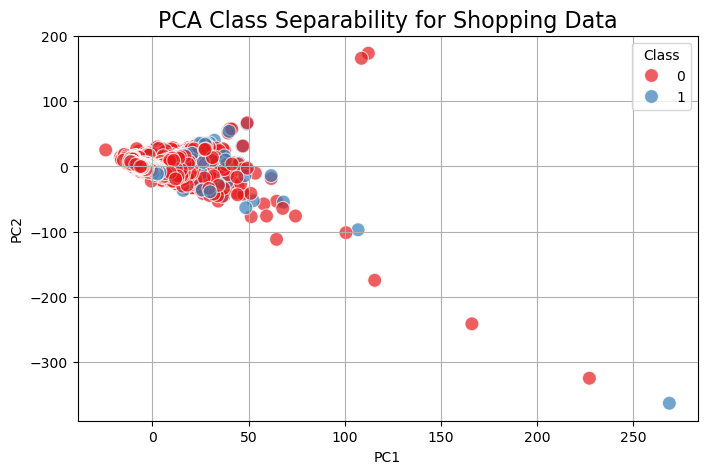

In [10]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
X_pca

loadings = pca.components_

pc_contributions = pd.DataFrame(X_pca,
                                #index=X.columns,
                                columns=["PC1", "PC2"]
                               )
pc_contributions['target'] = mod_Y

# pc_contributions_abs = np.abs(pc_contributions)

# pc1_top_contributors = pc_contributions_abs['PC1'].sort_values(ascending=False)
# pc2_top_contributors = pc_contributions_abs['PC2'].sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.scatterplot(data=pc_contributions, x='PC1', y='PC2', hue='target', palette='Set1', s=100, alpha=0.7)
plt.title('PCA Class Separability for Shopping Data', fontsize=16)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Class')
plt.grid(True)
plt.show()

In [11]:
loadings = pca.components_
pc_contributions = pd.DataFrame(loadings.T,
                                index=mod_X.columns,
                                columns=["PC1", "PC2"]
                               )
n = 10
print("Top contributors to PC1:\n", pc_contributions["PC1"].abs().sort_values(ascending=False).head(n))
print("Top contributors to PC2:\n", pc_contributions["PC2"].abs().sort_values(ascending=False).head(n))

Top contributors to PC1:
 inter_session_time_sum     0.131352
session_recency_max        0.124278
start_year_stddev          0.123634
session_recency_stddev     0.123516
start_year_cv              0.122467
start_month_stddev         0.122169
inter_purchase_time_sum    0.121813
start_yearday_stddev       0.121284
purchase_recency_max       0.120812
start_week_stddev          0.118624
Name: PC1, dtype: float64
Top contributors to PC2:
 time_to_click_stddev       0.130569
length_stddev              0.130139
time_to_purchase_stddev    0.129392
time_to_view_stddev        0.129144
time_to_click_mean         0.127090
time_to_purchase_mean      0.127086
time_to_cart_mean          0.126784
time_to_cart_stddev        0.125979
length_mean                0.124964
time_to_view_mean          0.122260
Name: PC2, dtype: float64


### 4 Evaluating Different Models

#### Report (Continued)

Next, we wanted to build a model to predict the likelihood of churn. We focused on 5 different algorithms to test the training data against, and determine which model performs better. The algorithms under consideration were KNN, Naïve Bayes, Random Forest, Gradient Boosting, and SVM. SVM performed the best out of all these models, with Naïve Bayes model performing the worst.

To run these models, we first processed the dataset and applied a standard scaler.  Then the dataset was split into training and testing data, with 50% being moved to training and 50% being sent to training data. I followed this ratio due to the size of the data, and the time needed computationally to run the models. Next was to set up the code to find the best parameters for each predictive algorithm mentioned in the previous paragraph. The best parameters for each method are listed in Appendix, Part 8. Using the best parameters for each model, I was able to generate the following scores: accuracy, precision, recall, f1_score and a confusion matrix. I also generated classification reports for each prediction model. The definitions for the 4 scoring metrics are listed in the appendix.

Sections 4.1 to 4.5 show my code and the output for each of the ML models below.

#### 4.1 KNN

In [14]:
#Setup KNN Pipeline
knn_clf_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn_clf",KNeighborsClassifier())
])

#Grid of n-neighbors to test against
param_grid = {'n_neighbors': list(range(0, 4))}

# Grid search with 5-fold cross-validation
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)


GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [0, 1, 2, 3]}, scoring='accuracy')

In [15]:

#Best parameter listed below
print("Best k for KNN:", grid_search.best_params_)
print(" ")

# Use the best estimator to predict
best_knn = grid_search.best_estimator_
y_pred_best_knn = best_knn.predict(X_test)

# Predict and evaluate
print("Confusion Matrix (KNN):")
print(confusion_matrix(y_test, y_pred_best_knn))
print("\nClassification Report (KNN):")
print(classification_report(y_test, y_pred_best_knn))

#y_train_pred = grid_search.best_estimator_.predict(X_train)

#Do score assessment
print("Accuracy Score for KNN")
print(accuracy_score(y_test, y_pred_best_knn))
print("Precision Score for KNN")
print(precision_score(y_test, y_pred_best_knn, average='weighted'))
print("Recall Score for KNN")
print(recall_score(y_test, y_pred_best_knn, average='weighted'))
print("F1 Score for KNN")
f1_macro = f1_score(y_test, y_pred_best_knn, average='weighted')
print(f1_macro)

Best k for KNN: {'n_neighbors': 3}
 
Confusion Matrix (KNN):
[[33308  4850]
 [ 7852 10295]]

Classification Report (KNN):
              precision    recall  f1-score   support

           0       0.81      0.87      0.84     38158
           1       0.68      0.57      0.62     18147

    accuracy                           0.77     56305
   macro avg       0.74      0.72      0.73     56305
weighted avg       0.77      0.77      0.77     56305

Accuracy Score for KNN
0.774407246248113
Precision Score for KNN
0.767504327509602
Recall Score for KNN
0.774407246248113
F1 Score for KNN
0.7685052703715802


#### 4.2 Naive Bayes

In [18]:
# Apply naive bayes to the data


# Initialize and train the classifier
nb = GaussianNB()
nb.fit(X_train, y_train)


GaussianNB()

In [19]:

# Predict and evaluate
y_pred_nb = nb.predict(X_test)
print("Confusion Matrix (Naive Bayes):")
print(confusion_matrix(y_test, y_pred_nb))
print("\nClassification Report (Naive Bayes):")
print(classification_report(y_test, y_pred_nb))

#Do score assessment
print("Accuracy Score for Naive bayes")
print(accuracy_score(y_test, y_pred_nb))
print("Precision Score for Naive bayes")
print(precision_score(y_test, y_pred_nb, average='weighted'))
print("Recall Score for Naive bayes")
print(recall_score(y_test, y_pred_nb, average='weighted'))
print("F1 Score for Naive bayes")
f1_macro = f1_score(y_test, y_pred_nb, average='weighted')
print(f1_macro)

Confusion Matrix (Naive Bayes):
[[13990 24168]
 [ 2100 16047]]

Classification Report (Naive Bayes):
              precision    recall  f1-score   support

           0       0.87      0.37      0.52     38158
           1       0.40      0.88      0.55     18147

    accuracy                           0.53     56305
   macro avg       0.63      0.63      0.53     56305
weighted avg       0.72      0.53      0.53     56305

Accuracy Score for Naive bayes
0.5334694964923187
Precision Score for Naive bayes
0.7178576951732385
Recall Score for Naive bayes
0.5334694964923187
F1 Score for Naive bayes
0.52678046232743


#### 4.3 Random Forest

In [22]:
#Random forest tuning

rnd_clf = RandomForestClassifier(n_estimators=23, 
                                 max_leaf_nodes=8)
n_folds=5
param_grid = {
   'random_state': [-1,0,1,]
 }

#tree_clf = DecisionTreeClassifier(max_depth=2) 


clf = GridSearchCV(rnd_clf, param_grid, cv=n_folds, scoring='accuracy') 
clf.fit(X_train, y_train)
y_pred_rf = clf.predict(X_test)
#rnd_clf.oob_score_
#print(accuracy_score(y_test, y_pred_rf))

In [23]:
# Show best parameters

# Use best estimator to predict
best_model = clf.best_estimator_
y_train_pred_clf = best_model.predict(X_train)
y_test_pred_clf = best_model.predict(X_test)


print("Best parameters for Random Forest:", clf.best_params_)
print("Confusion Matrix (Random Forest):")
print(confusion_matrix(y_test, y_test_pred_clf))
print("\nClassification Report (Random Forest):")
print(classification_report(y_test, y_test_pred_clf))

# print("Confusion Matrix for Support Vector Machine")
# confusion_mat = confusion_matrix(y_test, y_test_pred_clf)
# print(confusion_mat)

# Evaluate
#print("Train Accuracy:", accuracy_score(y_train, y_train_pred_clf))
#print("Test Accuracy:", accuracy_score(y_test, y_test_pred_clf))

#Do score assessment
print("Accuracy Score for Random Forest")
print(accuracy_score(y_test, y_test_pred_clf))
print("Precision Score for Random Forest")
print(precision_score(y_test, y_test_pred_clf, average='macro'))
print("Recall Score for Random Forest")
print(recall_score(y_test, y_test_pred_clf, average='macro'))
print("F1 Score for Random Forest")
f1_macro = f1_score(y_test, y_test_pred_clf, average='macro')
print(f1_macro)


Best parameters for Random Forest: {'random_state': 1}
Confusion Matrix (Random Forest):
[[36192  1966]
 [ 6572 11575]]

Classification Report (Random Forest):
              precision    recall  f1-score   support

           0       0.85      0.95      0.89     38158
           1       0.85      0.64      0.73     18147

    accuracy                           0.85     56305
   macro avg       0.85      0.79      0.81     56305
weighted avg       0.85      0.85      0.84     56305

Accuracy Score for Random Forest
0.8483616019891661
Precision Score for Random Forest
0.850565323903512
Recall Score for Random Forest
0.7931619297561046
F1 Score for Random Forest
0.8125257279270695


#### 4.4 Gradient Boost

In [26]:
#Gradient boost tuning

n_folds=5
grdnt_pipeline = Pipeline([
    ('grd',GradientBoostingClassifier(max_depth=2, random_state=4))])

param_grid = {
   'grd__n_estimators':  [0,10,20,30],
   'grd__learning_rate':  [0.4,0.5,0.6,0.7]
 }

gboost = GridSearchCV(grdnt_pipeline, param_grid, cv=n_folds, scoring='accuracy', n_jobs=-1) 
gboost.fit(X_train, y_train)

gboost.best_params_

#Looks like best model has 9 n_estimators and 0.5 learning rate {'grd__learning_rate': 0.1, 'grd__n_estimators': 10}

{'grd__learning_rate': 0.4, 'grd__n_estimators': 30}

In [31]:
# Show best parameters

# Use best estimator to predict
best_model = gboost.best_estimator_
y_train_pred_gboost = best_model.predict(X_train)
y_test_pred_gboost = best_model.predict(X_test)

print("Best parameters for Gradient Boost:", clf.best_params_)

print("Confusion Matrix for Gradient Boost")
confusion_mat = confusion_matrix(y_test, y_test_pred_gboost)
print(confusion_mat)
print("\nClassification Report (Gradient Boost):")
print(classification_report(y_test, y_test_pred_gboost))
print(" ")

#Do score assessment
print("Accuracy Score for Gradient Boost")
print(accuracy_score(y_test, y_test_pred_gboost))
print("Precision Score for Gradient Boost")
print(precision_score(y_test, y_test_pred_gboost, average='macro'))
print("Recall Score for Gradient Boost")
print(recall_score(y_test, y_test_pred_gboost, average='macro'))
print("F1 Score for Gradient Boost")
f1_macro = f1_score(y_test, y_test_pred_gboost, average='macro')
print(f1_macro)

Best parameters for Gradient Boost: {'random_state': 1}
Confusion Matrix for Gradient Boost
[[36002  2156]
 [ 5981 12166]]

Classification Report (Gradient Boost):
              precision    recall  f1-score   support

           0       0.86      0.94      0.90     38158
           1       0.85      0.67      0.75     18147

    accuracy                           0.86     56305
   macro avg       0.85      0.81      0.82     56305
weighted avg       0.85      0.86      0.85     56305

 
Accuracy Score for Gradient Boost
0.8554835272178315
Precision Score for Gradient Boost
0.8534999701620138
Recall Score for Gradient Boost
0.8069559647051164
F1 Score for Gradient Boost
0.8239290901853609


#### 4.5 SVM

In [34]:
#Setting up Support Vector Machine pipeline find the best algorithm
svm_clf_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm_clf", SVC(random_state=4))
])

# Using the example in the question, but adding what I think are tuning parameters
param_grid = [
    {'svm_clf__C': [ 0.0, 0.1 ], 'svm_clf__kernel': ['linear']},
    {'svm_clf__C': [ 0.01, 0.1], 'svm_clf__kernel': ['poly']}
]

#Run grid search to find best model fit.
grid_search = GridSearchCV(svm_clf_pipeline, param_grid, cv=2, n_jobs=-1)
grid_search.fit(X_train, y_train)

#This line gives me the best parameter or model name
#grid_search.best_params_
#clf-0.1 and linear

GridSearchCV(cv=2,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('svm_clf', SVC(random_state=4))]),
             n_jobs=-1,
             param_grid=[{'svm_clf__C': [0.0, 0.1],
                          'svm_clf__kernel': ['linear']},
                         {'svm_clf__C': [0.01, 0.1],
                          'svm_clf__kernel': ['poly']}])

In [35]:
# Show best parameters

# Use best estimator to predict
best_model = grid_search.best_estimator_
#y_train_pred_svm = best_model.predict(X_train)
y_test_pred_svm = best_model.predict(X_test)

print("Best parameters for Support Vector Machine:", grid_search.best_params_)
print("Confusion Matrix for Support Vector Machine")
confusion_mat = confusion_matrix(y_test, y_test_pred_svm)
print(confusion_mat)
print("\nClassification Report (Gradient Boost):")
print(classification_report(y_test, y_test_pred_svm))
print(" ")


#Do score assessment
print("Accuracy Score for Support Vector Machine")
print(accuracy_score(y_test, y_test_pred_svm))
print("Precision Score for Support Vector Machine")
print(precision_score(y_test, y_test_pred_svm, average='macro'))
print("Recall Score for Support Vector Machine")
print(recall_score(y_test, y_test_pred_svm, average='macro'))
print("F1 Score for Support Vector Machine")
f1_macro = f1_score(y_test, y_test_pred_svm, average='macro')
print(f1_macro)

Best parameters for Support Vector Machine: {'svm_clf__C': 0.1, 'svm_clf__kernel': 'linear'}
Confusion Matrix for Support Vector Machine
[[36369  1789]
 [ 7358 10789]]

Classification Report (Gradient Boost):
              precision    recall  f1-score   support

           0       0.83      0.95      0.89     38158
           1       0.86      0.59      0.70     18147

    accuracy                           0.84     56305
   macro avg       0.84      0.77      0.80     56305
weighted avg       0.84      0.84      0.83     56305

 
Accuracy Score for Support Vector Machine
0.8375455110558565
Precision Score for Support Vector Machine
0.8447481054147292
Recall Score for Support Vector Machine
0.7738247615586962
F1 Score for Support Vector Machine
0.7952945539282328


#### Best parameters for each predictive model
The best tuning parameters are listed for each model. We did not have one for Naive Bayes.

In [84]:
print("Best k for KNN:", grid_search.best_params_)
print("Best parameters for Random Forest:", clf.best_params_)
print("Best parameters for Gradient Boost:", clf.best_params_)
print("Best parameters for Support Vector Machine:", grid_search.best_params_)

Best k for KNN: {'svm_clf__C': 0.1, 'svm_clf__kernel': 'linear'}
Best parameters for Random Forest: {'random_state': 1}
Best parameters for Gradient Boost: {'random_state': 1}
Best parameters for Support Vector Machine: {'svm_clf__C': 0.1, 'svm_clf__kernel': 'linear'}


#### 4.6 Graph that shows accuracy, precision, recall, and f1-score for each of the 5 prediction models.

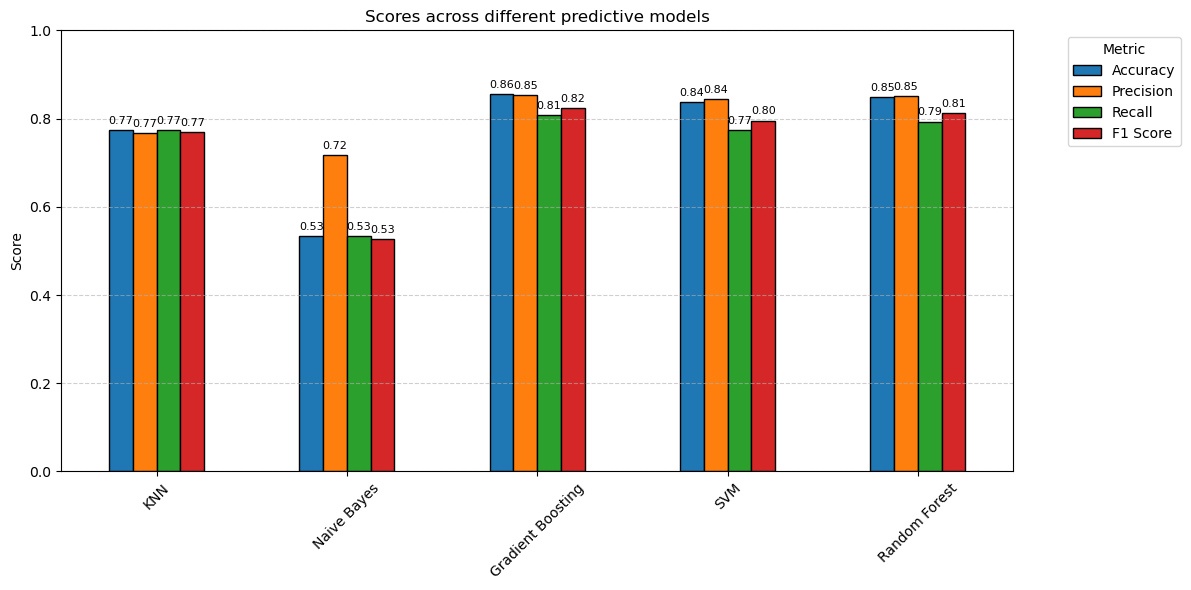

In [39]:
# Put all 5 scores df into 1 df
all_scores_df = pd.DataFrame({
    'KNN': knn_scores,
    'Naive Bayes': nb_scores,
    'Gradient Boosting': gboost_scores,
    'SVM': svm_scores,
    'Random Forest': rforest_scores
})

all_scores_df = all_scores_df.T
ax = all_scores_df.plot(kind='bar', figsize=(12, 6), edgecolor='black')
plt.title('Scores across different predictive models')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=8)
plt.tight_layout()
plt.show()

#### Report (continued)

For this exercise, I chose to keep all the variables in the dataset that I used to train the models. However, in the interest of time, I was able to only assess which was the best algorithm to use in a predictive model. As there were 270 dimensions with 112,610 observations, it is computationally expensive to assess how each variable is, in terms of normality and variability. Furthermore, it was challenging to understand which variable has the highest impact in predicting the churn. One method I tried was to use a RandomForestClassifier to assess what is the most important (or 10 most important features). The most important factor are how recent the sessions are, how recent a purchase was made, and how many recent purchases were made by the customer. This dataset could be useful for a retention manager to strategize on customer engagement to retain them.

In the previous graph, we notice that Gradient Boosting performed better over the other 5 models, with an accuracy score of 0.86, although SVM and Random Forest were very close contenders for runner-up. Gradient Boosting also performed best when using Precision, Recall and F1 Score metrics as well.


### Using these steps to find the variable of most importance

                   Variable  How Important?
89      session_recency_min        0.325462
92     purchase_recency_min        0.044939
152  purchase_number_stddev        0.031722
40          haspurchase_sum        0.028039
28     purchase_number_mean        0.023981
59      purchase_number_sum        0.022703
121     purchase_number_max        0.022264
120     session_recency_max        0.006242
185     purchase_recency_cv        0.005432
184  inter_purchase_time_cv        0.005172


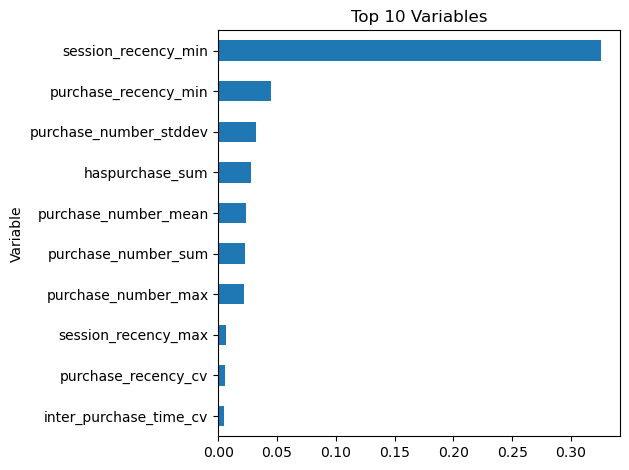

In [41]:

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)
importances = model.feature_importances_
feature_importance_df = pd.DataFrame({'Variable': mod_X.columns,'How Important?': importances}).sort_values(by='How Important?', ascending=False)
print(feature_importance_df.head(10))
feature_importance_df.head(10).plot(kind='barh', x='Variable', y='How Important?', legend=False)
plt.gca().invert_yaxis()
plt.title('Top 10 Variables')
plt.tight_layout()
plt.show()

#### Report (continued)
In the previous code chunk, I wanted to assess which variables are of importance. I noticed that the session recency, purchase recency, and purchase numbers had the highest importance to the prediction model. The takeaway for a stakeholder would be that focusing on keeping the customer engaged with the retail website, and making sure they are purchasing merchandise, with or without incentives, would likely help to retain them as paying customers.

I had some limitations. I was unable to implement some feedback from the previous Project Assignment 4 report. I was unable to fine-tune the RF and SVM models, now was able to find any feature importances for RF, SVM and Gradient Boosting, as my computer had some computational limits.

To summarize, I chose to use an e-commerce dataset with 112,610 observations, and 276 dimensions to determine what is the best predictive model to use to predict the likelihood of customer churn. I found that Gradient Boosting was the best performing model overall, followed very closely by Random Forest, and then Support Vector Machine models. The worse performing model was Naïve Bayes. In a real world setting, this model maybe used to predict the likelihood of customer churn using the target_event variable to determine whether a customer churned or not.